In [687]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

In [688]:
BASE_DIR = Path.cwd().parent/ 'datasets'

In [689]:
BASE_DIR

PosixPath('/home/toqeer-yasir/Documents/repos/deep-learning/Deep_learning/datasets')

In [690]:
df = pd.read_csv(BASE_DIR/'Admission_Predict_Ver1.1.csv')

In [691]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [692]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [693]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [694]:
df.shape

(500, 9)

In [695]:
df = df.drop(columns=['Serial No.'])

In [696]:
df.head(1)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92


In [697]:
X, y = df.iloc[:,:-1].values, df.iloc[:,-1].values

In [698]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=None)

In [699]:
from sklearn.preprocessing import MinMaxScaler

In [700]:
scaler = MinMaxScaler()

In [701]:
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)

In [702]:
model = Sequential()

In [703]:
model.add(Input(shape=(7,)))
model.add(Dense(7, activation='relu'))
model.add(Dense(244, activation='relu'))
model.add(Dense(1, activation='linear'))

In [704]:
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 244)            │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │           245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,253 (8.80 KB)

 Trainable params: 2,253 (8.80 KB)

 Non-trainable params: 0 (0.00 B)

In [705]:
model.compile(loss='mean_squared_error', optimizer='Adam', metrics=['accuracy'])

In [706]:
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=120)

Epoch 1/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.0000e+00 - loss: 0.4192 - val_accuracy: 0.0000e+00 - val_loss: 0.1567
Epoch 2/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.0702 - val_accuracy: 0.0000e+00 - val_loss: 0.0120
Epoch 3/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: 0.0242 - val_accuracy: 0.0000e+00 - val_loss: 0.0305
Epoch 4/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.0256 - val_accuracy: 0.0000e+00 - val_loss: 0.0138
Epoch 5/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 0.0122 - val_accuracy: 0.0000e+00 - val_loss: 0.0108
Epoch 6/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 0.0115 - val_accuracy: 0.0000e+00 - val_loss: 0.0096
Epoch 7/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: 0.0093 - val_accuracy: 0.0000e+00 - val_loss: 0.0086
Epoch 8/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 

In [707]:
y_pred = model.predict(X_test_scaled)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [708]:
from sklearn.metrics import r2_score

In [709]:
r2_score(y_test, y_pred)*100

80.50171063763052

In [710]:
import matplotlib.pyplot as plt

In [711]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

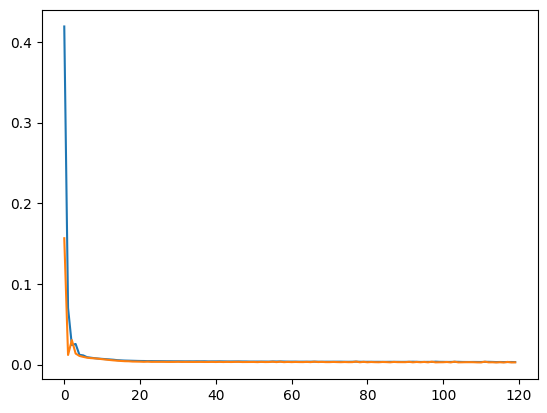

In [712]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

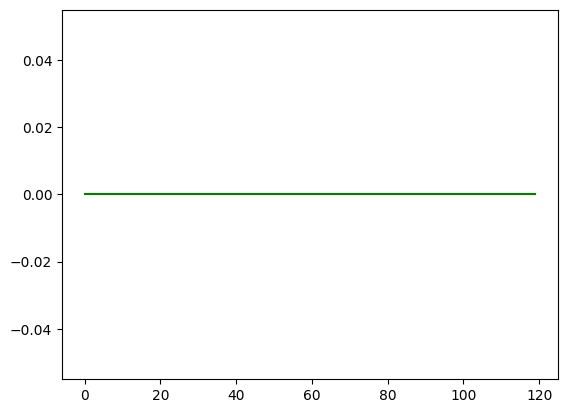

In [713]:
plt.plot(history.history['accuracy'], color = 'red'),
plt.plot(history.history['val_accuracy'], color = 'green')